Start by importing the dataset and path check

In [4]:
import os
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

dataset_root = Path("/Users/cindyshing/Documents/git/ECS171/Project/Data/Tennis-Player-Actions-Dataset-for-Human-Pose-Estimation")

images_dir = dataset_root / "images"
ann_dir = dataset_root / "annotations"

print("dataset_root exists:", dataset_root.exists())
print("images_dir exists:", images_dir.exists())
print("ann_dir exists:", ann_dir.exists())

# list a few files to confirm
print("\nTop-level contents:", [p.name for p in dataset_root.iterdir()])
print("\nAnnotations contents:", [p.name for p in ann_dir.iterdir()][:10])
print("\nImages sample:", [p.name for p in images_dir.iterdir()][:10])

dataset_root exists: True
images_dir exists: True
ann_dir exists: True

Top-level contents: ['.DS_Store', 'images', 'annotations']

Annotations contents: ['backhand.json', 'forehand.json', 'serve.json', 'ready_position.json']

Images sample: ['.DS_Store', 'forehand', 'backhand', 'serve', 'ready_position']


load JSON poses files (all poses)

In [6]:
def load_json(json_path: Path):
    with open(json_path, "r") as f:
        return json.load(f)

json_files = sorted(ann_dir.glob("*.json"))
print("JSON files found:", [p.name for p in json_files])

coco_by_pose = {p.stem: load_json(p) for p in json_files}
print("Loaded poses:", list(coco_by_pose.keys()))

JSON files found: ['backhand.json', 'forehand.json', 'ready_position.json', 'serve.json']
Loaded poses: ['backhand', 'forehand', 'ready_position', 'serve']


Basic summary of the dataset

In [7]:
summary_rows = []
for pose, coco in coco_by_pose.items():
    n_images = len(coco.get("images", []))
    n_anns = len(coco.get("annotations", []))
    cats = coco.get("categories", [])
    summary_rows.append({
        "pose_file": pose,
        "num_images": n_images,
        "num_annotations": n_anns,
        "num_categories": len(cats),
        "category_names": ", ".join([c.get("name","") for c in cats])[:120]
    })

summary_df = pd.DataFrame(summary_rows).sort_values("pose_file")
summary_df


,pose_file,num_images,num_annotations,num_categories,category_names
0,backhand,500,500,1,Backhand
1,forehand,500,500,1,Forehand
2,ready_position,500,500,1,Ready_Position
3,serve,500,500,1,Serve


In [13]:
kp_rows = []
for pose, coco in coco_by_pose.items():
    for ann in coco.get("annotations", []):
        kps = ann.get("keypoints", [])
        if not kps:
            continue
        
        # keypoints length should be 3*K
        K = len(kps) // 3
        xs = kps[0::3]
        ys = kps[1::3]
        vs = kps[2::3]  # visibility flags
        
        kp_rows.append({
            "pose": pose,
            "image_id": ann.get("image_id"),
            "num_keypoints": ann.get("num_keypoints", None),
            "K": K,
            "visible_count": int(np.sum(np.array(vs) > 0)),
            "labeled_count": int(np.sum(np.array(vs) == 2)) if len(vs) else None,
        })

kp_df = pd.DataFrame(kp_rows)
kp_df.head()


,pose,image_id,num_keypoints,K,visible_count,labeled_count
0,backhand,10001,18,18,18,15
1,backhand,10002,18,18,18,13
2,backhand,10003,18,18,18,14
3,backhand,10004,18,18,18,14
4,backhand,10005,18,18,18,13


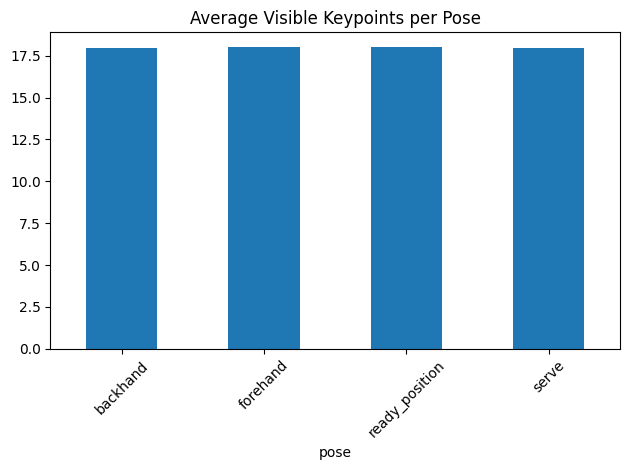

In [14]:
kp_df.groupby("pose")["visible_count"].mean().plot(kind="bar", rot=45)
plt.title("Average Visible Keypoints per Pose")
plt.tight_layout()
plt.show()


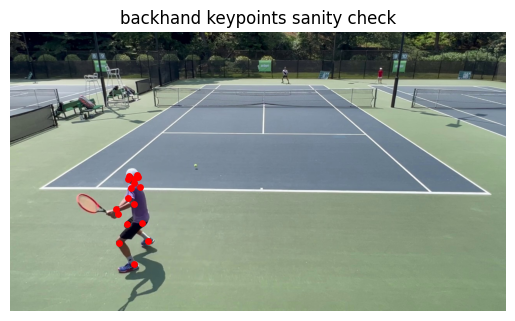

In [17]:
import random

pose = "backhand"
coco = coco_by_pose[pose]

img_index = {img["id"]: img for img in coco["images"]}
ann = random.choice(coco["annotations"])

img_path = images_dir / pose / img_index[ann["image_id"]]["file_name"]
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")

kps = ann["keypoints"]
xs = kps[0::3]
ys = kps[1::3]
vs = kps[2::3]

for x, y, v in zip(xs, ys, vs):
    if v > 0:
        plt.scatter(x, y, c="red", s=15)

plt.title(f"{pose} keypoints sanity check")
plt.show()


From our exploratory data analysis, we found that the dataset is evenly balanced across the four pose classes, with 500 images for each pose. All images share the same resolution (1280×720), and each annotation contains 18 keypoints, which keeps the data consistent across samples. Most keypoints are visible in each image, with some partial labeling, but this does not vary much between poses. We also visually inspected several images with keypoints overlaid and confirmed that the annotations align correctly with the player’s body.